### 馬達論文研究
### 第三步 遷移式學習
### 馬達C 8000RPM 當作基準模型
### 8000 RPM 可能是最適合巡航的轉速，因為它提供足夠的推力又不會過度耗電。
### CNN_11 Layers

In [1]:
print("Befor Logger")

Befor Logger


In [2]:
# --- logging bootstrap (auto-added) ---
import importlib
import logger as _logger_mod
_logger_mod = importlib.reload(_logger_mod)
save_plot = _logger_mod.save_plot
setup_logger = _logger_mod.setup_logger
tee_std_to_file = _logger_mod.tee_std_to_file

LOG, RUN_PATHS = setup_logger('notebook', console=False)
_tee_ctx = tee_std_to_file(RUN_PATHS.log_file)
_tee_ctx.__enter__()
import atexit
atexit.register(_tee_ctx.__exit__, None, None, None)

# Ensure TensorFlow releases GPU/graph resources on exit
try:
    import tensorflow as tf
    atexit.register(tf.keras.backend.clear_session)
except Exception:
    pass

# Auto-save matplotlib figures on plt.show()
try:
    import matplotlib.pyplot as plt
    if not getattr(plt, '_ancestor_save_plot_patched', False):
        plt._ancestor_save_plot_patched = True
        _orig_show = plt.show
        import time
        plt._ancestor_show_in_progress = False
        plt._ancestor_last_save_ts = 0.0

        def _show_and_save(*args, **kwargs):
            if getattr(plt, '_ancestor_show_in_progress', False):
                return _orig_show(*args, **kwargs)
            now = time.monotonic()
            if now - float(getattr(plt, '_ancestor_last_save_ts', 0.0)) < 0.5:
                return _orig_show(*args, **kwargs)
            plt._ancestor_show_in_progress = True
            try:
                save_plot(plt, LOG, RUN_PATHS)
            except Exception:
                pass
            try:
                return _orig_show(*args, **kwargs)
            finally:
                plt._ancestor_last_save_ts = time.monotonic()
                try:
                    plt.close(plt.gcf())
                except Exception:
                    pass
                plt._ancestor_show_in_progress = False

        plt.show = _show_and_save
except Exception:
    pass
# --- end logging bootstrap ---


I0000 00:00:1778140428.132750   82575 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778140428.175310   82575 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 AMX_FP16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778140429.383492   82575 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
print("After Logger")

After Logger


In [4]:
# 匯入所需函式庫
import os
import logging
import absl.logging
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder, RobustScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, Concatenate, Add, Activation, GlobalAveragePooling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from gpu_utils import device_scope, DEVICE
warnings.filterwarnings("ignore")

[gpu_utils] GPU x1 已啟用：['/physical_device:GPU:0']


In [5]:
# 資料準備與處理
def load_and_preprocess_data(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, 'T1', '8000rpm', screws, 'T1_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [6]:
# 加載資料
rootDir = os.getcwd()
dataDir = os.path.join(rootDir, 'data')
stepDir = os.path.join(dataDir, 'Step-1')
modelDirectory = os.path.join(stepDir, 'model')
myfeatureDirectory = os.path.join(stepDir, 'myfeature')

screws_list = ['8screws', '1screws', '2screws', '3screws', '4screws']
datasets_T1 = load_and_preprocess_data(myfeatureDirectory, screws_list)

In [7]:
# 合併資料
combined_data = pd.concat(datasets_T1, ignore_index=True)

In [8]:
# **手動定義標籤順序**
desired_order = ['8screws', '1screws', '2screws', '3screws', '4screws']
label_mapping = {screw: idx for idx, screw in enumerate(desired_order)}
combined_data['screws'] = combined_data['screws'].map(label_mapping)

In [9]:
# 標籤編碼
le_screws = LabelEncoder()
combined_data['screws'] = le_screws.fit_transform(combined_data['screws'])

In [10]:
# 確認標籤映射是否正確
print("自訂 Label Mapping:")
for label, num in label_mapping.items():
    print(f"{label}: {num}")

自訂 Label Mapping:
8screws: 0
1screws: 1
2screws: 2
3screws: 3
4screws: 4


In [11]:
# 資料分割
X = combined_data.drop(['screws'], axis=1).values
y_screws = combined_data['screws'].values

In [12]:
# 劃分訓練與測試集
X_train, X_test, y_train_screws, y_test_screws = train_test_split(
    X, y_screws, test_size=0.2, random_state=42
)

In [13]:
# 標準化特徵
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# 建立 CNN 模型
def build_cnn_model(input_shape, num_classes):

    # 定義輸入層
    input_layer = tf.keras.Input(shape=input_shape)

    # 第一層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu', padding='same')(input_layer)

    # 第二層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 第三層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 第四層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = Flatten()(x)

    # 第五層卷積層
    x = Dense(16, activation='relu')(x)
    x = Dropout(0.3)(x)

    # 第六層卷積層
    output = Dense(num_classes, activation='softmax', name="Screw_Number_Output")(x)


    # 定義模型    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=["sparse_categorical_crossentropy"],
        metrics=["accuracy"]
    )
    return model


In [15]:
# 模型參數
num_classes = len(np.unique(y_train_screws))

In [16]:
print(f"[Training] Device: {DEVICE}")
with device_scope():
    # 建立 CNN 模型
    cnn_model = build_cnn_model((X_train.shape[1], 1), num_classes)
    
    # 訓練模型
    history = cnn_model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train_screws,
        validation_data=(
            X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
            y_test_screws
        ),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    )

[Training] Device: /GPU:0


I0000 00:00:1778140430.860347   82575 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 42511 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/100


I0000 00:00:1778140432.542153   82685 service.cc:153] XLA service 0x7fe958033a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778140432.542194   82685 service.cc:161]   StreamExecutor [0]: NVIDIA L40S, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778140432.568843   82685 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778140432.814785   82685 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778140432.850170   82685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2402__.41


57/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4300 - loss: 1.4120

I0000 00:00:1778140436.740711   82685 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1778140437.218118   82683 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2402__.41


75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.4899 - loss: 1.3044 - val_accuracy: 0.5630 - val_loss: 1.1447
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5349 - loss: 1.1213 - val_accuracy: 0.6622 - val_loss: 1.0145
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6065 - loss: 1.0319 - val_accuracy: 0.7630 - val_loss: 0.9172
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6944 - loss: 0.9462 - val_accuracy: 0.8487 - val_loss: 0.8257
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7513 - loss: 0.8515 - val_accuracy: 0.9378 - val_loss: 0.7266
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7942 - loss: 0.7572 - val_accuracy: 0.9765 - val_loss: 0.6090
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8304 - loss: 0.6480 - val_accuracy: 0.9866 - val_loss: 0.4790
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8620 - loss: 0.5334 - val_accuracy: 0.9899 - val_loss: 0

In [17]:
# 清除
tf.keras.backend.clear_session()

In [18]:
# 模型架構
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 105, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 105, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 103, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 51, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 49, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Screw_Number_Output (Dense)     │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.51 KB)

 Trainable params: 5,333 (20.83 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,668 (41.68 KB)

In [19]:
# 評估模型
results = cnn_model.evaluate(
    X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    y_test_screws
)
print(f"Loss: {results[0]:.4f}, Accuracy: {results[1]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.9013e-05 
Loss: 0.0000, Accuracy: 1.0000


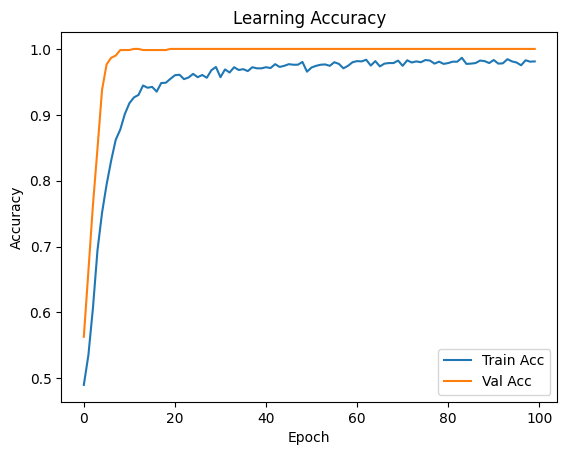

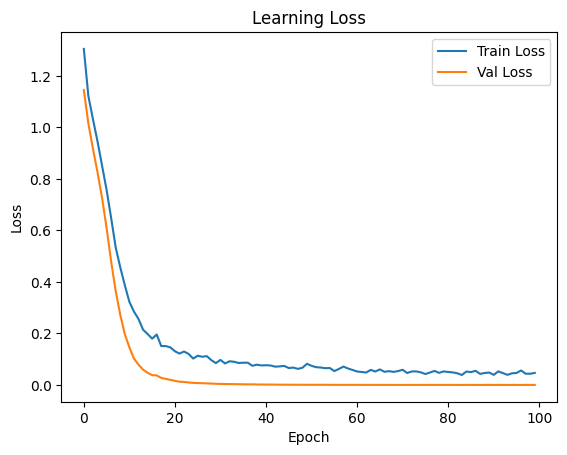

In [20]:
# 繪製學習曲線
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


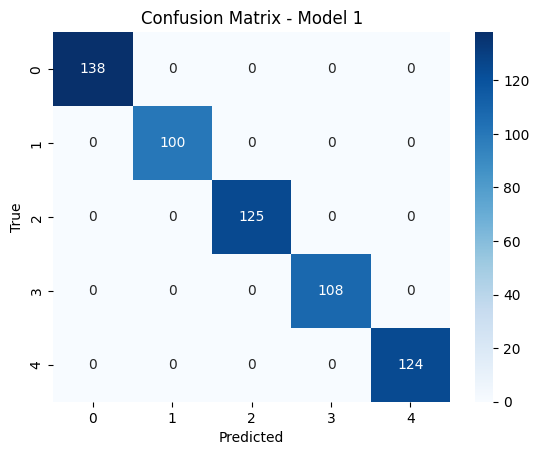

In [21]:
# 混淆矩陣繪製
def plot_confusion_matrix(y_true, y_pred, label_encoder, title):
    """
    繪製混淆矩陣，顯示數字映射標籤
    """
    cm = confusion_matrix(y_true, y_pred)
    numeric_labels = range(len(label_encoder.classes_))  # 使用數字標籤
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=numeric_labels, yticklabels=numeric_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 預測並繪製混淆矩陣
y_pred_screw = cnn_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1)).argmax(axis=1)
plot_confusion_matrix(y_test_screws, y_pred_screw, le_screws, "Confusion Matrix - Model 1")

In [22]:
# 儲存模型
cnn_model.save(os.path.join(modelDirectory, 'CNN_C8000.keras'))